In [1]:
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# data read and augmentation

In [3]:
train_data_gen= ImageDataGenerator(
    preprocessing_function= preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
val_data_gen= ImageDataGenerator(preprocessing_function= preprocess_input)
test_data_gen= ImageDataGenerator(preprocessing_function= preprocess_input)

In [4]:
train_gen= train_data_gen.flow_from_directory(
                "../data/train",
                batch_size= 32,
                target_size=(224,224),
                class_mode= 'categorical',
                shuffle=True,
                seed=42,
                color_mode='rgb'
                )
val_gen= val_data_gen.flow_from_directory(
            "../data/valid",
            batch_size=42,
            color_mode='rgb',
            seed=42,
            shuffle=True,
            class_mode='categorical',
            target_size=(224, 224)
)
test_gen= test_data_gen.flow_from_directory(
                "../data/test",
                batch_size=42,
                target_size=(224,224),
                color_mode='rgb',
                class_mode= 'categorical',
                shuffle= True,
                seed=42
                )

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


In [5]:
class_labels = train_gen.class_indices
class_labels

{'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0,
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1,
 'normal': 2,
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}

# Model Creation & training

In [6]:
from tensorflow.keras.applications import MobileNetV2 

In [7]:
base= MobileNetV2(
    input_shape=(224, 224, 3),
    include_top= False,
    weights="imagenet")
base.trainable = False
model= keras.Sequential([
    base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(4, activation='softmax')
])

In [8]:
model.compile(optimizer='Adam', 
              loss='CategoricalCrossentropy',
              metrics= ['accuracy'])
batch_size= 16
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights= True)

In [9]:
hist= model.fit(train_gen, validation_data= val_gen, epochs=30, callbacks=[early_stop])

Epoch 1/30


20/20 [==============================] - 11s 426ms/step - loss: 1.4043 - accuracy: 0.3883 - val_loss: 1.1333 - val_accuracy: 0.4583
Epoch 2/30
20/20 [==============================] - 7s 350ms/step - loss: 0.9965 - accuracy: 0.5579 - val_loss: 0.9659 - val_accuracy: 0.5417
Epoch 3/30
20/20 [==============================] - 7s 354ms/step - loss: 0.9306 - accuracy: 0.5889 - val_loss: 0.8794 - val_accuracy: 0.5972
Epoch 4/30
20/20 [==============================] - 7s 340ms/step - loss: 0.8081 - accuracy: 0.6770 - val_loss: 0.8719 - val_accuracy: 0.5417
Epoch 5/30
20/20 [==============================] - 7s 340ms/step - loss: 0.7007 - accuracy: 0.7194 - val_loss: 0.8223 - val_accuracy: 0.6806
Epoch 6/30
20/20 [==============================] - 7s 343ms/step - loss: 0.6623 - accuracy: 0.7357 - val_loss: 0.8134 - val_accuracy: 0.6528
Epoch 7/30
20/20 [==============================] - 7s 355ms/step - loss: 0.6114 - accuracy: 0.7586 - val_loss: 0.7611 - val_accuracy: 0.6806
Epo

KeyboardInterrupt: 

In [10]:
test_loss, test_acc = model.evaluate(test_gen)

8/8 [==============================] - 2s 239ms/step - loss: 0.7163 - accuracy: 0.6540


NameError: name 'hist' is not defined

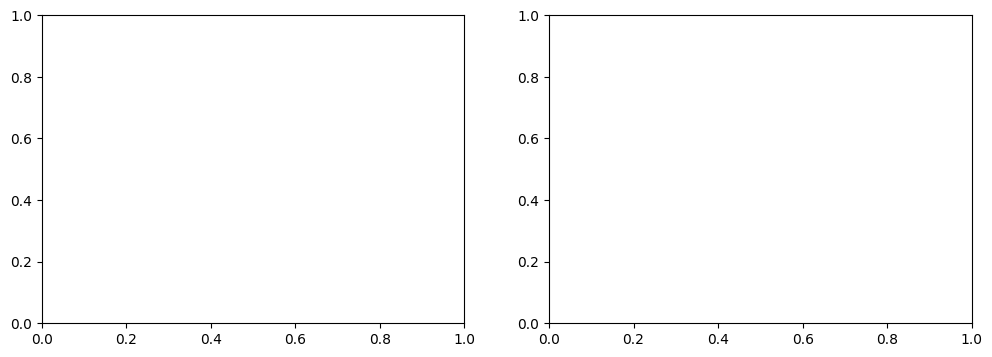

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist.history["loss"], label="train")
ax1.plot(hist.history["val_loss"], label="validation")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist.history["accuracy"], label="train")
ax2.plot(hist.history["val_accuracy"], label="validation")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.show()


8/8 [==============================] - 2s 172ms/step
              precision    recall  f1-score   support

       adeno       0.39      0.55      0.46       120
  large_cell       0.21      0.24      0.22        51
      normal       0.13      0.13      0.13        54
    squamous       0.29      0.11      0.16        90

    accuracy                           0.30       315
   macro avg       0.26      0.26      0.24       315
weighted avg       0.29      0.30      0.28       315



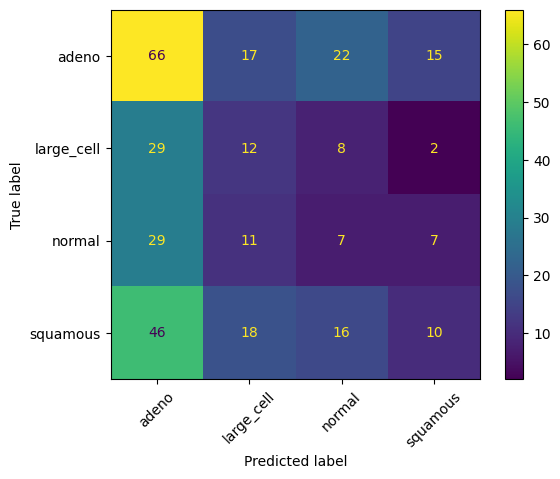

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

probs  = model.predict(test_gen)
y_pred = probs.argmax(axis=1)          # probabilities -> predicted class index
y_true = test_gen.classes              # true labels (needs shuffle=False!)
names  = ["adeno", "large_cell", "normal", "squamous"]

print(classification_report(y_true, y_pred, target_names=names))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=names, xticks_rotation=45)
plt.show()
